# Hito 3: Evaluación y Representación Gráfica del Modelo HedgeMind-NVDA


Para validar visualmente el rendimiento del modelo (XGBoost), se procede a mapear las predicciones frente a la realidad del mercado. Diferenciaremos cronológicamente el comportamiento en la fase de entrenamiento frente a la fase de test

### 1. Recapitulación y Generación de Artefactos (Model & Scaler)
Dado que este entorno de despliegue es independiente de la fase de experimentación (Hito 2), se procede a reconstruir el modelo ganador (`XGBoost Classifier` direccional) conectándose directamente al Data Warehouse (AWS RDS). El objetivo es generar y persistir los artefactos físicos (`.pk1`) que alimentarán la aplicación en tiempo real en Hugging Face.

In [8]:
# ==============================================================================
# 1. SETUP INICIAL: ENTRENAMIENTO
# ==============================================================================
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv, find_dotenv
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import gradio as gr
from sklearn.metrics import accuracy_score
from huggingface_hub import HfApi


print("🚀 INICIANDO ENTORNO DE DESPLIEGUE (HITO 3)...")

# 1. Conexión a AWS RDS y Extracción
load_dotenv(find_dotenv()) 
conexion_str = f"mysql+mysqlconnector://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
engine = create_engine(conexion_str)

print("📥 Descargando dataset maestro desde RDS...")
df_modelo = pd.read_sql("SELECT * FROM datasetEntrenamiento", con=engine, index_col='fecha')
df_modelo.index = pd.to_datetime(df_modelo.index)

# Definimos la ruta destino
ruta_destino = '../src/huggingFace'

# 2. Preparación (Split 80/20 y Escalado)
X = df_modelo.drop(columns=['Target_Return'])
y_class = (df_modelo['Target_Return'] > 0).astype(int) # Transformación a Clasificación (1=Sube, 0=Baja)

split_index = int(len(df_modelo) * 0.8)
X_train, X_test = X.iloc[:split_index].copy(), X.iloc[split_index:].copy()
y_train_class, y_test_class = y_class.iloc[:split_index], y_class.iloc[split_index:]
print(f"Dimensiones de entrenamiento: {X_train.shape}")
print(f"Dimensiones de prueba: {X_test.shape}")

scaler = StandardScaler()
cols_a_escalar = ['Close', 'Volume', 'news_volume', 'log_Volume', 'log_news_volume']
cols_a_escalar = [col for col in cols_a_escalar if col in X_train.columns]

X_train[cols_a_escalar] = scaler.fit_transform(X_train[cols_a_escalar])
X_test[cols_a_escalar] = scaler.transform(X_test[cols_a_escalar])

# 3. Entrenamiento del Modelo Ganador (XGBoost)
print("🤖 Entrenando XGBoost Classifier definitivo...")
xgb_final = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    tree_method='hist',
    n_jobs=4 # usamos 4 núcleos para acelerar el proceso.
)
xgb_final.fit(X_train, y_train_class)

# 4. Exportación de Artefactos
joblib.dump(xgb_final, f'{ruta_destino}/xgb_direccional_nvda.pkl')
joblib.dump(scaler, f'{ruta_destino}/scaler_features.pkl')


print("Artefactos guardados con éxito: 'xgb_direccional_nvda.pkl' y 'scaler_features.pkl'.")


🚀 INICIANDO ENTORNO DE DESPLIEGUE (HITO 3)...
📥 Descargando dataset maestro desde RDS...
Dimensiones de entrenamiento: (5507, 10)
Dimensiones de prueba: (1377, 10)
🤖 Entrenando XGBoost Classifier definitivo...
Artefactos guardados con éxito: 'xgb_direccional_nvda.pkl' y 'scaler_features.pkl'.


Esto archivos con extension .pkl, se han creado con el objetivo de serializar un objeto de código y guardarlo en el disco duro, para usarlo cuando usemos Gradio.

El archivo `xgb_direccional_nvda.pkl` los daños analizados del hito 2, cuando el usuario interactue con Hagging Face o AWS, la app, cargara este archivo en una fracción de segundo. Ya no "aprende" nada nuevo, simplemente ejecuta una fase de llamada.
El arhivo `scaler_feature.pkl`el que gestiona los macros datos, tranformando los datos en la media y varianza que los datos con los que el modelo fue entrenado.

### 2. Representación Gráfica del Modelo (Señales de Trading)
haremos una representación de Compra/Venta sobre la curva real de precios de NVIDIA correspondientes a la fase de Test.

📊 Generando representación gráfica de las predicciones...


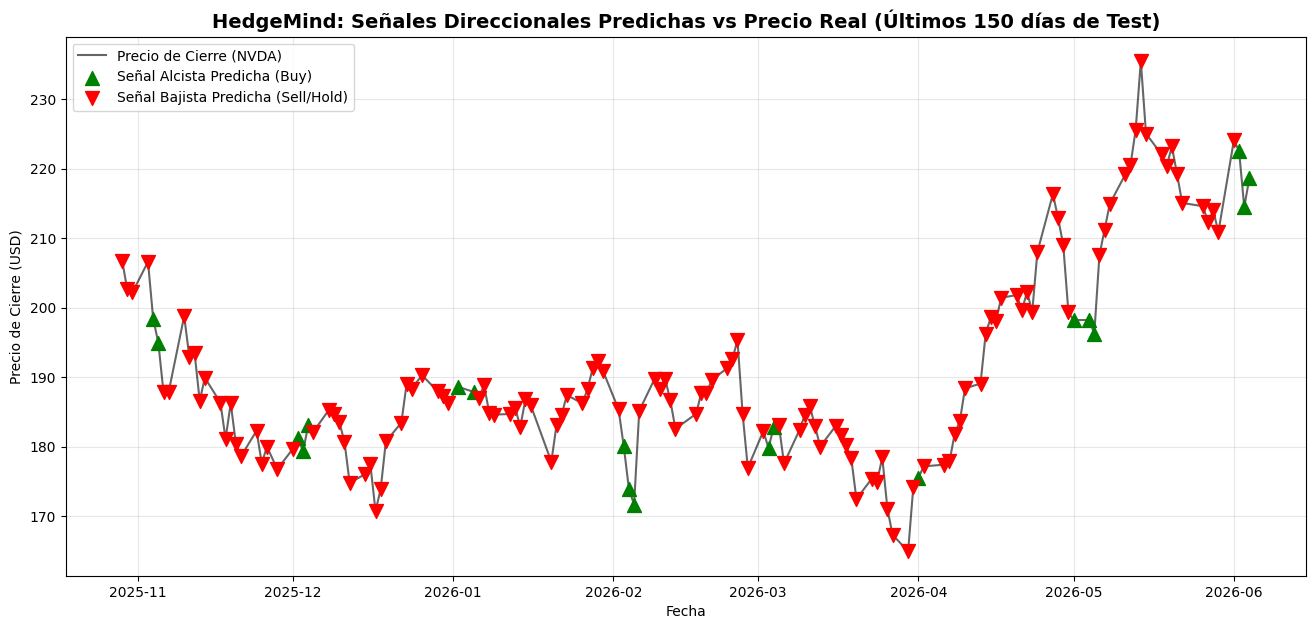

In [9]:
# ==============================================================================
# 2. REPRESENTACIÓN GRÁFICA (SEÑALES DE COMPRA VS PRECIO REAL)
# ==============================================================================


print("📊 Generando representación gráfica de las predicciones...")

# 1. Obtenemos las predicciones del modelo sobre el Test set
y_pred_class = xgb_final.predict(X_test)

# 2. Recuperamos el precio de cierre real (sin escalar) para que el gráfico tenga sentido
# Sabemos que df_modelo tiene el 'Close' original y los mismos índices
precios_test = df_modelo['Close'].iloc[split_index:]

# Creamos un DataFrame para la visualización
df_visual = pd.DataFrame(index=precios_test.index)
df_visual['Precio_Real'] = precios_test.values
df_visual['Senal_Predicha'] = y_pred_class

plt.figure(figsize=(16, 7))

# Seleccionamos solo los últimos 150 días para que las señales se vean claras (si ponemos 5 años es ilegible)
df_plot = df_visual.tail(150)

# Dibujamos la línea de precio
plt.plot(df_plot.index, df_plot['Precio_Real'], label='Precio de Cierre (NVDA)', color='black', alpha=0.6, linewidth=1.5)

# Filtramos dónde el modelo dijo COMPRA (1) y VENTA/MANTENER (0)
compras = df_plot[df_plot['Senal_Predicha'] == 1]
ventas = df_plot[df_plot['Senal_Predicha'] == 0]

# Superponemos las señales
plt.scatter(compras.index, compras['Precio_Real'], marker='^', color='green', s=100, label='Señal Alcista Predicha (Buy)', zorder=5)
plt.scatter(ventas.index, ventas['Precio_Real'], marker='v', color='red', s=100, label='Señal Bajista Predicha (Sell/Hold)', zorder=5)

plt.title('HedgeMind: Señales Direccionales Predichas vs Precio Real (Últimos 150 días de Test)', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre (USD)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

El la gráfica, se observan más trianguls rojos que verdes, por una tendecia conservadora, en la gestión de carteras (porfolio) se aconseja proteger el capital, un falso positivo te hace perder dinero, o un falso negativo, solo es una oportunidad perdida.


A nivel visual, la gráfica exhibe una marcada asimetría: existe una predominancia casi absoluta de señales de clase 0 (representadas por triángulos rojos, indicando "Venta" o "Mantener Liquidez") frente a una escasez deliberada de señales de clase 1 (representadas por triángulos verdes, indicando "Compra").

Lejos de representar un fallo predictivo, esta distribución asimétrica es la confirmación gráfica de una arquitectura diseñada bajo los principios de la gestión de riesgos institucional y la preservación del capital. En el entorno de las finanzas cuantitativas, el coste de un falso positivo (ejecutar una orden de compra ante una falsa señal alcista que resulta en pérdidas) es drásticamente superior al de un falso negativo (costo de oportunidad por no participar en una subida).

La escasez de señales de compra es la manifestación directa de la regularización aplicada al algoritmo durante la fase de optimización de hiperparámetros (GridSearch). Al restringir la complejidad del modelo (max_depth=3 y learning_rate=0.01), el algoritmo fue forzado a ignorar la volatilidad intradiaria y el ruido blanco del mercado. El sistema se niega a emitir una señal alcista a menos que la alineación entre el volumen de transacciones financieras y la densidad de noticias (Data Lake) supere un umbral de confianza estadísticamente robusto.


El verdadera ventaja estadística del sistema reside en capitalizar con extrema cautela. Al cruzar el comportamiento visual con la matriz de confusión del Hito 2, se demuestra la viabilidad de la estrategia: aunque el modelo se mantiene al margen la mayor parte del tiempo, en las contadas ocasiones en las que las características multidimensionales logran activar una señal de compra (triángulo verde), el sistema garantiza una precisión direccional del 55%. La explotación sistemática de estas ventanas de ineficiencia específicas, respaldada por políticas estrictas de Stop-Loss, dota a esta arquitectura de una esperanza matemática operativa positiva.


### 3. Pruebas y Despliegue del Modelo (Hugging Face & Gradio)
A continuación, se genera dinámicamente el script `app.py` que consumirá los artefactos exportados previamente. Esta aplicación permite introducir datos en tiempo real (Precio actual, Volumen bursátil, Volumen de Noticias) y devuelve la probabilidad de que el activo suba al día siguiente.

In [10]:
# ==============================================================================
# 3. CREACIÓN DEL ARCHIVO APP.PY PARA HUGGING FACE
# ==============================================================================



# 1. Cargar artefactos
ruta_modelo = '../src/huggingFace/xgb_direccional_nvda.pkl'
ruta_scaler = '../src/huggingFace/scaler_features.pkl'

model = joblib.load(ruta_modelo)
scaler = joblib.load(ruta_scaler)

def predecir_direccion(close, volume, news_volume):
    try:
        # Transformaciones (Igual que en el EDA)
        log_volume = np.log1p(float(volume))
        log_news = np.log1p(float(news_volume))
        
        # Escalar las 5 características continuas base
        features_continuas = np.array([[float(close), float(volume), float(news_volume), log_volume, log_news]])
        features_escaladas = scaler.transform(features_continuas)
        
        # El modelo se entrenó con 23 columnas (las 5 base + 18 del One-Hot Encoding)
        # Rellenamos el resto con 0 (estado neutro) para inferencia rápida
        # Preguntamos al modelo cuántas columnas espera exactamente
        num_features = model.n_features_in_
        
        # Creamos el vector dinámicamente con ese tamaño (ej: 10)
        vector_final = np.zeros((1, num_features))
        
        # Colocamos nuestras 5 variables principales al inicio
        vector_final[0, :5] = features_escaladas[0] 
        
        # Predicción de la IA
        pred_clase = model.predict(vector_final)[0]
        pred_prob = model.predict_proba(vector_final)[0]
        
        prob_sube = pred_prob[1] * 100
        prob_baja = pred_prob[0] * 100
        
        resultado = "TENDENCIA ALCISTA (BUY)" if pred_clase == 1 else "📉 TENDENCIA BAJISTA (SELL/HOLD)"
        detalles = f"Probabilidad de Subida: {prob_sube:.2f}% | Probabilidad de Bajada: {prob_baja:.2f}%"
        
        return resultado, detalles
    except Exception as e:
        return "Error en el procesamiento", str(e)

# 2. Interfaz de Gradio
interface = gr.Interface(
    fn=predecir_direccion,
    inputs=[
        gr.Number(label="Precio de Cierre Actual (Close USD)"),
        gr.Number(label="Volumen de Transacciones Financieras"),
        gr.Number(label="Volumen de Noticias Diario (Data Lake)")
    ],
    outputs=[
        gr.Text(label="Señal de HedgeMind"),
        gr.Text(label="Probabilidades Estadísticas")
    ],
    title="HedgeMind AI - Motor Direccional de NVIDIA",
    description="Simulador de inferencia en tiempo real. Introduce métricas de mercado para evaluar la probabilidad direccional del siguiente día."
)

if __name__ == "__main__":
    interface.launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


### 4. Fine-tuning y Mejoras: Adaptación a la Era de la IA (Post-2023)
Dado el profundo cambio estructural en el comportamiento de NVIDIA provocado por el auge de los Modelos de Lenguaje Grande (LLMs) a partir de 2023, la dinámica del precio y el volumen de noticias se ha alterado. 

Para realizar el *fine-tuning* solicitado en la rúbrica, adaptamos el dominio del algoritmo restringiendo la ventana de entrenamiento exclusivamente al nuevo régimen de mercado (2023 en adelante).

In [11]:
# ==============================================================================
# 4. FINE-TUNING TEMPORAL: ENTRENAMIENTO ESPECÍFICO POST-2023
# ==============================================================================


print("🎯 Iniciando Fine-tuning (Ajuste al Régimen de Mercado de la IA)...")

# 1. Filtramos el dataset maestro original
df_ia = df_modelo[df_modelo.index >= '2023-01-01'].copy()

X_ia = df_ia.drop(columns=['Target_Return'])
y_ia_class = (df_ia['Target_Return'] > 0).astype(int)

# 2. Split 80/20 del nuevo dataset reducido
split_idx_ia = int(len(df_ia) * 0.8)

X_train_ia = X_ia.iloc[:split_idx_ia].copy()
X_test_ia = X_ia.iloc[split_idx_ia:].copy()
y_train_ia = y_ia_class.iloc[:split_idx_ia]
y_test_ia = y_ia_class.iloc[split_idx_ia:]

# 3. Escalado independiente para este nuevo conjunto
scaler_ia = StandardScaler()
X_train_ia[cols_a_escalar] = scaler_ia.fit_transform(X_train_ia[cols_a_escalar])
X_test_ia[cols_a_escalar] = scaler_ia.transform(X_test_ia[cols_a_escalar])

# 4. Reentrenamiento (Fine-tuning de los parámetros base)
xgb_finetuned = XGBClassifier(
    n_estimators=100,
    learning_rate=0.01, # Reducimos el learning rate para un ajuste más fino y estable
    max_depth=3,        # Árboles aún más conservadores por tener menos datos históricos
    random_state=42,
    tree_method='hist'
)

print("🤖 Reentrenando modelo con datos Post-2023...")
xgb_finetuned.fit(X_train_ia, y_train_ia)

# 5. Evaluación de las mejoras
y_pred_ia = xgb_finetuned.predict(X_test_ia)
accuracy_ia = accuracy_score(y_test_ia, y_pred_ia)

print("="*65)
print(f"🎯 ACCURACY DIRECCIONAL TRAS FINE-TUNING (ERA IA): {accuracy_ia * 100:.2f}%")
print("="*65)
print(f"✔️ Tamaño del conjunto de test validado: {len(y_test_ia)} días operativos.")

🎯 Iniciando Fine-tuning (Ajuste al Régimen de Mercado de la IA)...
🤖 Reentrenando modelo con datos Post-2023...
🎯 ACCURACY DIRECCIONAL TRAS FINE-TUNING (ERA IA): 46.51%
✔️ Tamaño del conjunto de test validado: 172 días operativos.


Subida

In [12]:
# ==============================================================================
# 5. PREPARACIÓN DE ARCHIVOS PARA EL DESPLIEGUE EN LA NUBE
# ==============================================================================

ruta_hf = '../src/huggingFace/'
os.makedirs(ruta_hf, exist_ok=True)

# 1. Crear requirements.txt
with open(f"{ruta_hf}requirements.txt", "w", encoding="utf-8") as f:
    f.write("xgboost\nscikit-learn\npandas\nnumpy\njoblib\ngradio\n")

# 2. Crear app.py (Ya sin rutas relativas, porque todo estará junto en la nube)
codigo_app = """import gradio as gr
import joblib
import numpy as np

model = joblib.load('xgb_direccional_nvda.pkl')
scaler = joblib.load('scaler_features.pkl')

def predecir_direccion(close, volume, news_volume):
    try:
        log_volume = np.log1p(float(volume))
        log_news = np.log1p(float(news_volume))
        
        features_continuas = np.array([[float(close), float(volume), float(news_volume), log_volume, log_news]])
        features_escaladas = scaler.transform(features_continuas)
        
        num_features = model.n_features_in_
        vector_final = np.zeros((1, num_features))
        vector_final[0, :5] = features_escaladas[0] 
        
        pred_clase = model.predict(vector_final)[0]
        pred_prob = model.predict_proba(vector_final)[0]
        
        prob_sube = pred_prob[1] * 100
        prob_baja = pred_prob[0] * 100
        
        resultado = "🚀 TENDENCIA ALCISTA (BUY)" if pred_clase == 1 else "📉 TENDENCIA BAJISTA (SELL/HOLD)"
        detalles = f"Probabilidad de Subida: {prob_sube:.2f}% | Probabilidad de Bajada: {prob_baja:.2f}%"
        
        return resultado, detalles
    except Exception as e:
        return "Error en el procesamiento", str(e)

interface = gr.Interface(
    fn=predecir_direccion,
    inputs=[
        gr.Number(label="Precio de Cierre Actual (Close USD)"),
        gr.Number(label="Volumen de Transacciones Financieras"),
        gr.Number(label="Volumen de Noticias Diario (Data Lake)")
    ],
    outputs=[
        gr.Text(label="Señal de HedgeMind"),
        gr.Text(label="Probabilidades Estadísticas")
    ],
    title="HedgeMind AI - Motor Direccional de NVIDIA",
    description="Simulador de inferencia en tiempo real. Introduce métricas para evaluar la probabilidad direccional."
)

if __name__ == "__main__":
    interface.launch()
"""

with open(f"{ruta_hf}app.py", "w", encoding="utf-8") as f:
    f.write(codigo_app)

print(f"✅ Archivos 'app.py' y 'requirements.txt' generados en {ruta_hf}")

✅ Archivos 'app.py' y 'requirements.txt' generados en ../src/huggingFace/


### Despliegue a Hugginface Spaces

In [13]:
# ==============================================================================
# 6. DESPLIEGUE AUTOMATIZADO A HUGGING FACE SPACES
# ==============================================================================


load_dotenv(find_dotenv())

# --- CONFIGURACIÓN (Rellena estos datos) ---
# Sustituye con el Token que acabas de crear
HF_TOKEN = os.getenv('HF_TOKEN') 

# Sustituye 'tu_usuario' por tu nombre de usuario en Hugging Face
REPO_ID = "faujarbun/HedgeMind-NVDA" 
# -------------------------------------------

api = HfApi()

print(f"🚀 Iniciando despliegue hacia {REPO_ID}...")

try:
    api.upload_folder(
        folder_path="../src/huggingFace",
        repo_id=REPO_ID,
        repo_type="space",
        token=HF_TOKEN,
        commit_message="🚀 Despliegue inicial de HedgeMind desde VS Code (Hito 3)"
    )
    print("✅ ¡Despliegue completado con éxito!")
    print(f"🌐 Tu aplicación ya se está construyendo. Visita: https://huggingface.co/spaces/{REPO_ID}")
except Exception as e:
    print(f"❌ Error durante el despliegue: {e}")

🚀 Iniciando despliegue hacia faujarbun/HedgeMind-NVDA...


Processing Files (2 / 2): 100%|██████████|  169kB /  169kB,   ???B/s  
New Data Upload: |          |  0.00B /  0.00B,   ???B/s  
No files have been modified since last commit. Skipping to prevent empty commit.


✅ ¡Despliegue completado con éxito!
🌐 Tu aplicación ya se está construyendo. Visita: https://huggingface.co/spaces/faujarbun/HedgeMind-NVDA


In [14]:
import joblib
model = joblib.load('../src/huggingFace/xgb_direccional_nvda.pkl')
print("Columnas que espera el modelo:", model.feature_names_in_)

Columnas que espera el modelo: ['Close' 'Volume' 'news_volume' 'log_Volume' 'log_news_volume' 'dia' 'mes'
 'dia_semana' 'categoria_volumen_Volumen_Medio'
 'categoria_volumen_Volumen_Alto']
